# Connecting detector time to the scan: a darkfield image

Notebooks 01–03 treated the detector on its own: events → sorted parts → clusters (≈ electrons),
each with a position on the detector and a time. In STEM the beam is also moving: a scan generator
steps the probe across the sample, and every electron belongs to the probe position at the moment
it arrived. An event detector has **no frames**. The only link between an electron and a probe
position is **time**.

This run records that link: the scan generator sends a pulse at the start of every scan line, and
the detector timestamps the pulses on its own clock, the same clock as the events. So

* **line** = the last pulse before the electron,
* **column** = time since that pulse ÷ dwell time per probe position,
* **which image** = where the electron landed on the detector. Electrons inside the bright-field
  (BF) disk make a BF image, and electrons scattered outside it make a **darkfield** (annular DF, ADF) image.

The run here is a 99 s acquisition on an NNO sample at 200 kV with a 15 mrad convergence angle (from the run folder's name). Its metadata leaves the scan size, dwell time and flyback at −1 ("unknown"), so all of it is
measured from the data here:

1. What the files hold, and where the pulses are (section 1).
2. The pulses: their units, period and timing jitter (section 2).
3. The diffraction pattern, the BF disk, and the virtual detectors (section 3).
4. A few lines in time: does the signal repeat from line to line? (section 4)
5. One pass over all 12 G events: sort, cluster, and count clusters by (detector ring, line, µs since the pulse) (section 5).
6. The image as a function of time, the flyback, and the dwell time (sections 6–8).
7. The darkfield image, and how contrast changes with collection angle (sections 9–10).
8. Line-sync jumps and other disturbances (section 11).

In [1]:
import json
import time
from itertools import pairwise
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numba
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle
from numpy.lib.stride_tricks import sliding_window_view
from plot_style import AQUA, BLUE, INK, MUTED, ORANGE, SEQUENTIAL, SERIES, YELLOW, no_grid

from kronos.cluster import cluster_tables, label_events, neighbor_time_gaps, summarize_clusters
from kronos.events import concat, event_columns, fine_steps, take
from kronos.sort import merge_sort, time_order

%matplotlib ipympl

## 0. The model: from a pulse train to an image

Before touching the data, here is what we expect, drawn for a toy scan of 8 probe positions per line.
The scan generator emits a pulse, then steps the probe across one line at a fixed dwell per
position, then sends the probe back to the start (**flyback**) and waits for the next pulse. Every
electron is assigned to the probe position at its arrival time, and the count of electrons per
(line, column) is the image. Electrons that arrive during the flyback belong to no position and are
dropped.

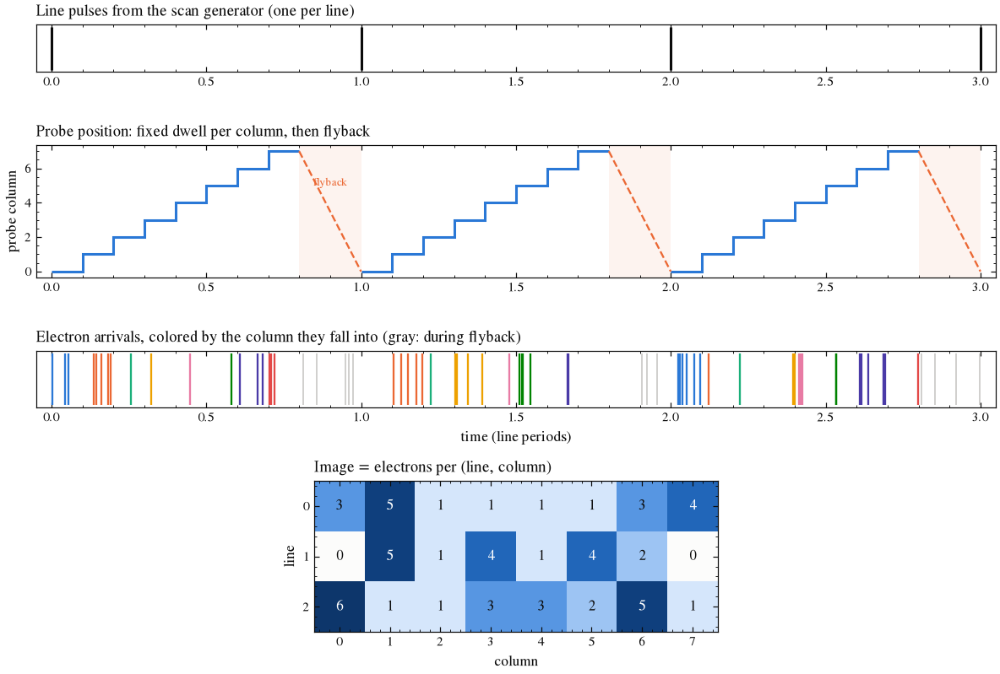

In [2]:
TOY_COLUMNS, TOY_ACTIVE = 8, 0.8  # toy scan: probe positions per line, fraction of the line period spent scanning
rng = np.random.default_rng(5)
arrivals = np.sort(rng.uniform(0, 3, 70))  # electron arrival times, in line periods
line_of = arrivals.astype(int)
since = arrivals - line_of
column_of = (since / TOY_ACTIVE * TOY_COLUMNS).astype(int)
scanning = column_of < TOY_COLUMNS

fig, (ax_pulse, ax_beam, ax_hits, ax_image) = plt.subplots(4, 1, figsize=(11, 7.5), gridspec_kw={'height_ratios': [0.5, 1.4, 0.6, 1.6]})
ax_pulse.vlines(np.arange(4), 0, 1, color=INK, lw=2)
ax_pulse.set(xlim=(-0.05, 3.05), yticks=[], title='Line pulses from the scan generator (one per line)')
for line in range(3):
    steps = line + np.arange(TOY_COLUMNS + 1) * TOY_ACTIVE / TOY_COLUMNS
    ax_beam.stairs(np.arange(TOY_COLUMNS), steps, color=BLUE, lw=2, baseline=None)
    ax_beam.plot([line + TOY_ACTIVE, line + 1], [TOY_COLUMNS - 1, 0], color=ORANGE, lw=1.5, ls='--')
    ax_beam.axvspan(line + TOY_ACTIVE, line + 1, color=ORANGE, alpha=0.08, lw=0)
ax_beam.text(TOY_ACTIVE + 0.1, 5, 'flyback', color=ORANGE, ha='center', fontsize=9)
ax_beam.set(xlim=(-0.05, 3.05), ylabel='probe column', title='Probe position: fixed dwell per column, then flyback')
colors = np.array(SERIES)[column_of % len(SERIES)]
ax_hits.vlines(arrivals[scanning], 0, 1, color=colors[scanning], lw=1.5)
ax_hits.vlines(arrivals[~scanning], 0, 1, color=MUTED, lw=1, alpha=0.5)
ax_hits.set(
    xlim=(-0.05, 3.05),
    yticks=[],
    xlabel='time (line periods)',
    title='Electron arrivals, colored by the column they fall into (gray: during flyback)',
)
toy_image = np.zeros((3, TOY_COLUMNS), int)
np.add.at(toy_image, (line_of[scanning], column_of[scanning]), 1)
ax_image.imshow(toy_image, cmap=SEQUENTIAL, vmin=0)
for (row, col), count in np.ndenumerate(toy_image):
    ax_image.text(col, row, count, ha='center', va='center', color=INK if count < toy_image.max() * 0.6 else 'white')
ax_image.set(title='Image = electrons per (line, column)', xlabel='column', ylabel='line', xticks=range(TOY_COLUMNS), yticks=range(3))
ax_image.grid(False)
plt.tight_layout()
plt.show()

## 1. What the run recorded

The run is 32 HDF5 files from the two halves of the chip (`ep0`, `ep1`), 16 files each. Besides the
event columns, every file has a set of trigger datasets. The metadata says which input was meant
to carry the scan (`ttl_timestamp`), but leaves the scan geometry unset:

In [3]:
run_directory = Path('/Users/7c2/Desktop/Projects/TimePix/data/2026_10_08_NNO_200kV_15mrad')
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
work_directory = project_root / 'outputs' / run_directory.name
files = sorted((run_directory / 'raw').glob('*.h5'))
meta = json.loads((run_directory / 'test.meta').read_text())

WIDTH, HEIGHT = 448, 512
TICK_S = 25e-9  # one toa tick
for block in ('acquisition', 'triggers', 'scan'):
    print(f'{block:>12}:', meta[block])

 acquisition: {'acquisition_type': 'scan', 'acquire_mode': 'event_list', 'acquire_time': 99.0, 'acquisition_start_time': '2026-10-08T12:22:42.325450'}
    triggers: {'acquire_trigger_start': 'internal', 'acquire_trigger_stop': 'internal', 'lvds_out_mode': 'follow_shutter', 'ttl_out_mode': 'follow_shutter', 'lvds_timestamp_mode': 're', 'ttl_timestamp_mode': 'fe'}
        scan: {'num_scans': -1, 'scan_dwell_time': -1.0, 'scan_flyback_time': -1.0, 'scan_size_x': -1, 'scan_size_y': -1, 'scan_input_trigger': 'ttl', 'scan_trigger_mode': 'pixel', 'scan_trigger_dataset': 'ttl_timestamp', 'scan_engine': 'none'}


12.2 G events in 32 files, 232 GB on disk
trigger datasets with no entries in any file: ['sw_lvds_fe_timestamp', 'ttl_timestamp', 'sw_ttl_re_timestamp', 'sw_ttl_fe_timestamp', 'sw_pulse_timestamp']


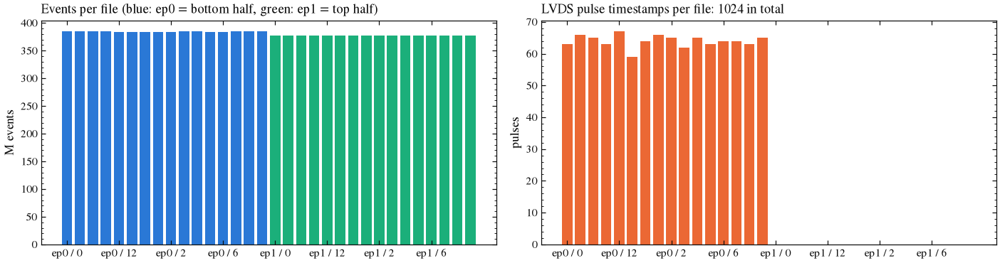

,events,toa_first,toa_last,lvds_timestamp,sw_lvds_re_timestamp,control
file,,,,,,
ep0_ch1_proc0,384368409,56770560,782712734,63,1024,1027
ep0_ch1_proc1,384339938,56786972,782728269,66,0,0
ep0_ch1_proc10,384463537,56934418,782876616,65,0,0
ep0_ch1_proc11,384346679,56690724,782884711,63,0,2


In [4]:
trigger_datasets = [
    'lvds_timestamp',
    'sw_lvds_re_timestamp',
    'sw_lvds_fe_timestamp',
    'ttl_timestamp',
    'sw_ttl_re_timestamp',
    'sw_ttl_fe_timestamp',
    'sw_pulse_timestamp',
    'control',
]
rows = []
for path in files:
    with h5py.File(path, 'r') as h5:
        rows.append(
            {'file': path.stem.removeprefix('test_'), 'events': len(h5['toa']), 'toa_first': int(h5['toa'][0]), 'toa_last': int(h5['toa'][-1])}
            | {name: len(h5[name]) for name in trigger_datasets}
        )
layout = pd.DataFrame(rows).set_index('file')
print(f'{layout.events.sum() / 1e9:.1f} G events in {len(files)} files, {sum(path.stat().st_size for path in files) / 1e9:.0f} GB on disk')
print('trigger datasets with no entries in any file:', [name for name in trigger_datasets if layout[name].sum() == 0])

fig, (ax_events, ax_pulses) = plt.subplots(1, 2, figsize=(13, 3.6))
position = np.arange(len(layout))
ax_events.bar(position, layout.events / 1e6, color=np.where(layout.index.str.startswith('ep0'), BLUE, AQUA))
ax_events.set(
    title='Events per file (blue: ep0 = bottom half, green: ep1 = top half)',
    ylabel='M events',
    xticks=position[::4],
    xticklabels=layout.index[::4].str.replace('_ch1_proc', ' / '),
)
ax_pulses.bar(position, layout.lvds_timestamp, color=ORANGE)
ax_pulses.set(
    title=f'LVDS pulse timestamps per file: {layout.lvds_timestamp.sum()} in total',
    ylabel='pulses',
    xticks=position[::4],
    xticklabels=layout.index[::4].str.replace('_ch1_proc', ' / '),
)
for ax in (ax_events, ax_pulses):
    ax.xaxis.minorticks_off()
plt.tight_layout()
plt.show()
layout.loc[:, (layout != 0).any()].head(4)

* `ttl_timestamp` is **empty**. The pulses arrived on the **LVDS** input instead, as 1024 rising
  edges (`lvds_timestamp_mode: re`), spread over the 16 `ep0` files the same way the events are.
  They must be gathered from all of them and sorted.
* `sw_lvds_re_timestamp` holds the same 1024 pulses again, all in one file (section 2 compares the two).
* `control` holds a few status packets (start/stop markers); they are not needed here.
* 1024 pulses for ~12 G events: one pulse per **line**, not per probe position.

## 2. The pulses

**Units.** Event `toa` counts 25 ns ticks. The pulse stamps are ~100× larger numbers. Read as
fine time units (1/128 tick = 195 ps, `kronos.events.fine_steps`), they fall inside the time span
of the events, as they must. Read as ticks, they would come minutes after the run ended.

events: 1.42 – 19.57 s;  pulses as fine units: 1.71 – 18.76 s;  as ticks: 219 – 2402 s


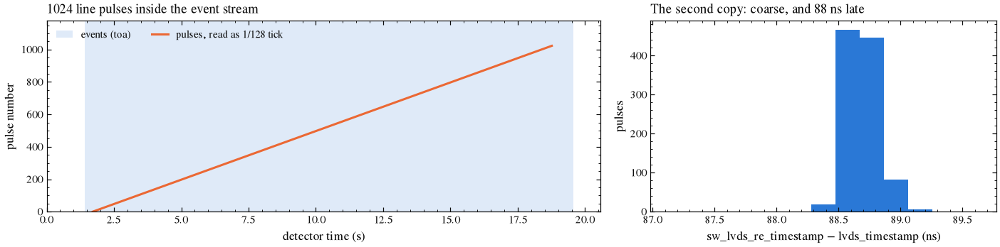

sw_lvds_re_timestamp is a multiple of 128 (whole ticks) for every pulse: True


In [5]:
pulse_list = []
for path in files:
    with h5py.File(path, 'r') as h5:
        pulse_list.append(h5['lvds_timestamp'][:].astype(np.int64))
pulses = np.sort(np.concatenate(pulse_list))  # line starts, in fine units (1/128 tick)
with h5py.File(files[0], 'r') as h5:
    sw_pulses = h5['sw_lvds_re_timestamp'][:].astype(np.int64)
n_lines = len(pulses)

events_span = layout.toa_first.min() * TICK_S, layout.toa_last.max() * TICK_S
pulse_seconds = pulses / fine_steps * TICK_S
print(
    f'events: {events_span[0]:.2f} – {events_span[1]:.2f} s;  pulses as fine units: {pulse_seconds[0]:.2f} – {pulse_seconds[-1]:.2f} s;  as ticks: {pulses[0] * TICK_S:.0f} – {pulses[-1] * TICK_S:.0f} s'
)

fig, (ax_span, ax_sw) = plt.subplots(1, 2, figsize=(13, 3.4), gridspec_kw={'width_ratios': [1.6, 1]})
ax_span.axvspan(*events_span, color=BLUE, alpha=0.15, lw=0, label='events (toa)')
ax_span.plot(pulse_seconds, np.arange(n_lines), color=ORANGE, lw=2, label='pulses, read as 1/128 tick')
ax_span.set(
    xlim=(0, events_span[1] + 1),
    ylim=(0, n_lines * 1.15),
    xlabel='detector time (s)',
    ylabel='pulse number',
    title=f'{n_lines} line pulses inside the event stream',
)
ax_span.legend(loc='upper left', ncols=2)
fine_ns = TICK_S / fine_steps * 1e9
offset = (sw_pulses - pulses) * fine_ns
ax_sw.hist(offset, bins=np.arange(offset.min() - fine_ns, offset.max() + 2 * fine_ns, fine_ns), color=BLUE)
ax_sw.set(xlabel='sw_lvds_re_timestamp − lvds_timestamp (ns)', ylabel='pulses', title='The second copy: coarse, and 88 ns late')
plt.tight_layout()
plt.show()
print(f'sw_lvds_re_timestamp is a multiple of 128 (whole ticks) for every pulse: {np.all(sw_pulses % fine_steps == 0)}')

The events start ~0.3 s before the first pulse and run ~0.8 s past the last one: the detector was
recording before the scan started. `sw_lvds_re_timestamp` is the same pulse rounded to a whole tick,
plus a fixed ~3.5-tick latency, so it is a coarse copy of `lvds_timestamp`. The rest of the notebook uses
`lvds_timestamp` (195 ps resolution, though nothing here needs better than a µs).

**Period.** The time between pulses is the line period.

typical period 666,641 ticks = 16.6660 ms (60.0023 Hz)
60 of 1023 periods differ from it by more than 5 µs; the others scatter by ±0.98 µs (1 σ)


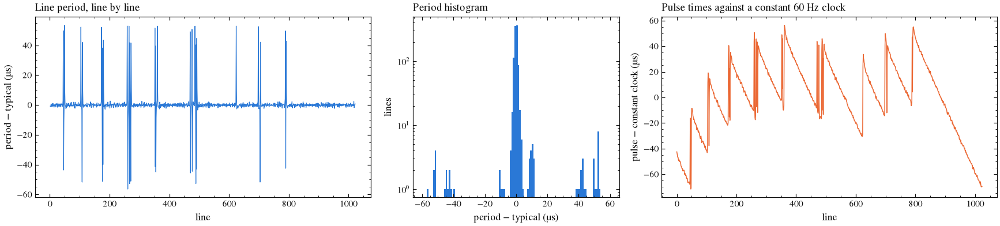

In [6]:
period = np.diff(pulses) / fine_steps  # ticks
typical_period = np.median(period)
line = np.arange(n_lines)
clock = np.polyfit(line, pulses / fine_steps, 1)  # the best constant-rate clock
drift_us = (pulses / fine_steps - np.polyval(clock, line)) * TICK_S * 1e6
print(f'typical period {typical_period:,.0f} ticks = {typical_period * TICK_S * 1e3:.4f} ms ({1 / (typical_period * TICK_S):.4f} Hz)')
calm = abs(period - typical_period) < 200
print(
    f'{(~calm).sum()} of {len(period)} periods differ from it by more than 5 µs; the others scatter by ±{period[calm].std() * TICK_S * 1e6:.2f} µs (1 σ)'
)

fig, (ax_period, ax_hist, ax_drift) = plt.subplots(1, 3, figsize=(16, 3.8), gridspec_kw={'width_ratios': [1.3, 0.8, 1.3]})
ax_period.plot(line[1:], (period - typical_period) * TICK_S * 1e6, color=BLUE, lw=0.8)
ax_period.set(xlabel='line', ylabel='period − typical (µs)', title='Line period, line by line')
ax_hist.hist((period - typical_period) * TICK_S * 1e6, bins=np.arange(-60, 61, 1), color=BLUE, log=True)
ax_hist.set(xlabel='period − typical (µs)', ylabel='lines', title='Period histogram')
ax_drift.plot(line, drift_us, color=ORANGE, lw=1)
ax_drift.set(xlabel='line', ylabel='pulse − constant clock (µs)', title='Pulse times against a constant 60 Hz clock')
plt.tight_layout()
plt.show()

* The period is **16.666 ms: 60.00 Hz, the mains frequency.** This is the usual STEM *line sync*:
  each scan line waits for the same phase of the mains, so mains hum in the lenses or the scan coils
  falls on the same column of every line. It shows up as a static distortion, not as wobbly edges.
* 963 of the 1023 periods agree to within 5 µs, with ~1 µs scatter (1 σ). In 60 places the period is
  off by 5–60 µs, usually a long period next to a short one.
* Against a constant clock the pulses run early by ~0.6 µs per line, then jump back by 40–90 µs over a
  few lines: a sawtooth between about −70 and +55 µs. It looks like the generator's own line clock
  running slightly fast and the mains sync pulling it back in steps. Either way, the pulses are *not* a constant-rate clock, so each line must
  be timed from **its own pulse**. Section 7 checks that the scan really follows each pulse.
* 1024 pulses at 60 Hz = 17 s for the frame. A square 1024 × 1024 scan within one line period
  leaves at most 16.3 µs per probe position.

## 3. The diffraction pattern and the virtual detectors

Take four lines from the middle of the frame (~45 M events, 67 ms) straight from the files. The
files are sorted up to a small disorder (notebook 01), so a bisection on `toa` finds each file's rows
for a time window, padded by `merge_sort`'s `max_disorder`. Then sort and cluster as in notebooks 01 and 02.

In [7]:
SAMPLE_FIRST, SAMPLE_LINES = 500, 4
DT_MAX = 1  # ticks; the neighbor-gap check below confirms it for this run
PAD = 1 << 16  # ticks: merge_sort's max_disorder, more than any file's step back in toa


def first_row(toa, t):
    """Row near the first toa >= t, by bisection on an HDF5 toa column sorted up to small disorder."""
    lo, hi = 0, len(toa)
    while hi - lo > 1000:
        middle = (lo + hi) // 2
        lo, hi = (middle, hi) if toa[middle] < t else (lo, middle)
    return lo


t_start, t_stop = pulses[SAMPLE_FIRST] // fine_steps, pulses[SAMPLE_FIRST + SAMPLE_LINES] // fine_steps
chunks = []
for path in files:
    with h5py.File(path, 'r') as h5:
        rows = slice(first_row(h5['toa'], t_start - PAD), first_row(h5['toa'], t_stop + PAD))
        chunks.append({name: h5[name][rows] for name in event_columns})
events = concat(chunks)
events = take(events, (events['toa'] >= t_start) & (events['toa'] < t_stop))
events = take(events, time_order(events['toa']))
labels = label_events(events['x'], events['y'], events['toa'], DT_MAX)
clusters = summarize_clusters(events, labels)
print(
    f'{len(events["toa"]):,} events -> {len(clusters):,} clusters ({len(events["toa"]) / len(clusters):.2f} events per electron) in {(t_stop - t_start) * TICK_S * 1e3:.1f} ms'
)

44,699,972 events -> 10,622,400 clusters (4.21 events per electron) in 66.7 ms


**Find the BF disk.** The disk is flat and far brighter than its surroundings, so threshold the
event image at half the disk's level: the center of the thresholded area is the disk center, and
its area gives the radius.

In [8]:
event_image = np.zeros((HEIGHT, WIDTH))
np.add.at(event_image, (events['y'], events['x']), 1)
cluster_image, _, _ = np.histogram2d(clusters.y, clusters.x, bins=(HEIGHT, WIDTH), range=((0, HEIGHT), (0, WIDTH)))

rows_grid, cols_grid = np.indices(event_image.shape)
disk_level = np.median(event_image[event_image > np.percentile(event_image, 99)])  # top 1 % of pixels: inside the disk
disk = event_image > disk_level / 2
center_x, center_y = cols_grid[disk].mean(), rows_grid[disk].mean()
bf_radius = np.sqrt(disk.sum() / np.pi)
print(f'BF disk: center ({center_x:.1f}, {center_y:.1f}) px, radius {bf_radius:.1f} px')

radius = np.hypot(cols_grid - center_x, rows_grid - center_y)
ring_index = radius.astype(int).ravel()  # 1 px wide rings
profile = np.bincount(ring_index, cluster_image.ravel()) / np.bincount(ring_index)
profile_r = np.arange(len(profile))

BF disk: center (204.3, 257.7) px, radius 55.0 px


**Virtual detectors.** Rather than fixing BF and ADF now, count clusters in **rings** around the disk
center, and choose the detector later by adding rings. The rings below split the BF disk into three, put
one ring on the disk edge, and divide the scattered electrons into six rings out to the shadow of the
aperture at r ≈ 210 px. The default **ADF** detector is rings 60–180 px. It starts just outside the
disk edge and stops short of the aperture rim.

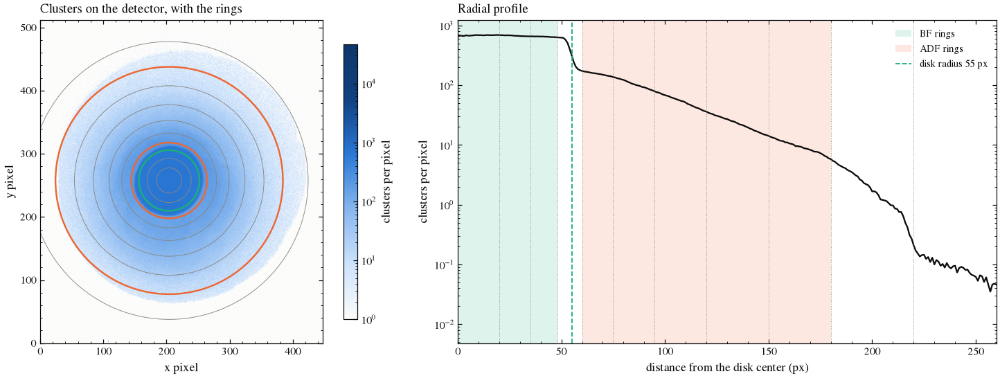

In [9]:
RING_EDGES = np.array([0, 20, 35, 48, 60, 75, 95, 120, 150, 180, 220], dtype=np.float64)  # px from the disk center
ring_names = [f'{a:.0f}–{b:.0f}' for a, b in pairwise(RING_EDGES)]
BF_RINGS = slice(0, 3)  # 0–48 px: inside the disk
ADF_RINGS = slice(4, 9)  # 60–180 px: scattered, inside the aperture
n_rings = len(RING_EDGES) - 1

fig, (ax_det, ax_prof) = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={'width_ratios': [1, 1.3]})
shown = ax_det.imshow(np.maximum(cluster_image, 1), origin='lower', cmap=SEQUENTIAL, norm=LogNorm())
fig.colorbar(shown, ax=ax_det, shrink=0.85, label='clusters per pixel')
for k, edge in enumerate(RING_EDGES[1:], start=1):
    color = ORANGE if k in (ADF_RINGS.start, ADF_RINGS.stop) else (AQUA if k == BF_RINGS.stop else MUTED)
    ax_det.add_patch(Circle((center_x, center_y), edge, fill=False, color=color, lw=1.6 if color != MUTED else 0.6))
ax_det.set(title='Clusters on the detector, with the rings', xlabel='x pixel', ylabel='y pixel')
ax_det.grid(False)
ax_prof.semilogy(profile_r, profile, color=INK, lw=1.5)
ax_prof.axvspan(0, RING_EDGES[BF_RINGS.stop], color=AQUA, alpha=0.15, lw=0, label='BF rings')
ax_prof.axvspan(RING_EDGES[ADF_RINGS.start], RING_EDGES[ADF_RINGS.stop], color=ORANGE, alpha=0.15, lw=0, label='ADF rings')
for edge in RING_EDGES:
    ax_prof.axvline(edge, color=MUTED, lw=0.6, ls=':')
ax_prof.axvline(bf_radius, color=AQUA, lw=1.2, ls='--', label=f'disk radius {bf_radius:.0f} px')
ax_prof.set(xlabel='distance from the disk center (px)', ylabel='clusters per pixel', title='Radial profile', xlim=(0, 260))
ax_prof.legend(loc='upper right')
plt.tight_layout()
plt.show()

The disk edge is sharp, a few pixels wide. Outside it the intensity falls ~100× before the aperture
shadow cuts it off at ~210 px. The single bright pixel near the bottom edge is a hot pixel, outside all rings.

**Events vs electrons.** At 200 kV an electron travels further in the 300 µm sensor than in the
lower-energy run of notebooks 01–03 (notebook 03, section 5). It fires **~4 pixels** here instead of 1–2.
Counting events instead of clusters would weight each electron by its cluster size. Two checks
that the clusters are clean at this flux: the neighbor-gap histogram (`neighbor_time_gaps`: is notebook 02's `dt_max = 1`
still right?), and the mean cluster size across the detector. A cluster that swallowed two electrons would
make clusters *larger* where the flux is high, in the disk.

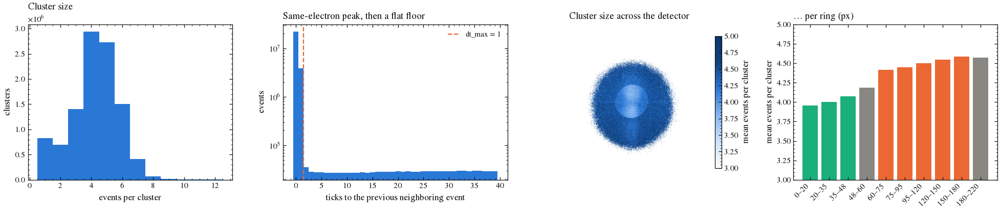

mean events per cluster by ring: {0: 3.95, 1: 4.0, 2: 4.07, 3: 4.19, 4: 4.41, 5: 4.45, 6: 4.5, 7: 4.55, 8: 4.58, 9: 4.57}


In [10]:
gaps = neighbor_time_gaps(events['x'], events['y'], events['toa'])
size_sum, _, _ = np.histogram2d(clusters.y, clusters.x, bins=(HEIGHT, WIDTH), range=((0, HEIGHT), (0, WIDTH)), weights=clusters.n_events)
ring_of_cluster = np.searchsorted(RING_EDGES, np.hypot(clusters.x - center_x, clusters.y - center_y), 'right') - 1
size_by_ring = clusters.n_events.groupby(ring_of_cluster).mean().reindex(range(n_rings))

fig, (ax_size, ax_gap, ax_map, ax_ring) = plt.subplots(1, 4, figsize=(18, 4), gridspec_kw={'width_ratios': [1, 1.1, 0.9, 1]})
ax_size.hist(clusters.n_events, bins=np.arange(0.5, 13.5), color=BLUE)
ax_size.set(xlabel='events per cluster', ylabel='clusters', title='Cluster size')
ax_gap.hist(gaps[(gaps >= 0) & (gaps < 40)], bins=np.arange(-0.5, 40.5), color=BLUE, log=True)
ax_gap.axvline(DT_MAX + 0.5, color=ORANGE, lw=1.5, ls='--', label=f'dt_max = {DT_MAX}')
ax_gap.set(xlabel='ticks to the previous neighboring event', ylabel='events', title='Same-electron peak, then a flat floor')
ax_gap.legend()
mean_size = np.where(cluster_image > 20, size_sum / np.maximum(cluster_image, 1), np.nan)
shown = ax_map.imshow(mean_size, origin='lower', cmap=SEQUENTIAL, vmin=3, vmax=5)
fig.colorbar(shown, ax=ax_map, shrink=0.85, label='mean events per cluster')
ax_map.set(title='Cluster size across the detector')
no_grid(ax_map)
ax_ring.bar(
    range(n_rings),
    size_by_ring,
    color=[AQUA if k < BF_RINGS.stop else (ORANGE if ADF_RINGS.start <= k < ADF_RINGS.stop else MUTED) for k in range(n_rings)],
)
ax_ring.set(xticks=range(n_rings), ylabel='mean events per cluster', title='… per ring (px)', ylim=(3, 5))
ax_ring.set_xticklabels(ring_names, rotation=45, ha='right')
ax_ring.xaxis.minorticks_off()
plt.tight_layout()
plt.show()
print('mean events per cluster by ring:', size_by_ring.round(2).to_dict())

* `dt_max = 1` still fits: a narrow same-electron peak at 0–1 tick, then a flat floor.
* Clusters in the bright disk are **smaller** (3.95 events) than outside (4.5), the opposite of
  merging. The likely reason is dead time: a disk pixel fires ~60 000 times per second and is busy for its ToT
  after each hit, so a neighbor's share of the next electron is sometimes lost. An image made from
  *event* counts would therefore under-weight the disk by ~10 % relative to the darkfield rings. Clusters avoid that.

## 4. A few lines in time

Now attach the clusters to the scan. `bin_clusters` is the whole reconstruction in a few lines: for
each cluster, find the last pulse before it (the line), the µs since that pulse (the time bin), and its
ring on the detector, and add one count to `cube[ring, line, time bin]`. The time axis is kept at
**1 µs**, far finer than a probe position. Grouping the bins into columns happens later, after the
dwell time is measured.

In [11]:
BIN_TICKS = 40  # 1 µs time bins
n_bins = int(period.max() // BIN_TICKS) + 1  # covers the longest line


@numba.njit
def bin_clusters(toa, x, y, pulses, center_x, center_y, ring_edges, bin_fine, cube):
    """Count clusters into cube[ring, line, time bin]: line = last pulse before the cluster
    (pulses in fine units), time bin = (time since that pulse) // bin_fine, ring from the distance to
    (center_x, center_y). Clusters before the first pulse, past the last bin or outside the rings are skipped."""
    n_rings, n_lines, n_bins = cube.shape
    for i in range(len(toa)):
        t = toa[i] * fine_steps  # ticks -> fine units
        line = np.searchsorted(pulses, t, 'right') - 1
        ring = np.searchsorted(ring_edges, np.hypot(x[i] - center_x, y[i] - center_y), 'right') - 1
        if line < 0 or line >= n_lines or ring >= n_rings:
            continue
        b = (t - pulses[line]) // bin_fine
        if b < n_bins:
            cube[ring, line, b] += 1


sample_cube = np.zeros((n_rings, SAMPLE_LINES, n_bins), np.uint16)
sample_pulses = pulses[SAMPLE_FIRST : SAMPLE_FIRST + SAMPLE_LINES + 1]
bin_clusters(
    clusters.toa.to_numpy(),
    clusters.x.to_numpy(),
    clusters.y.to_numpy(),
    sample_pulses,
    center_x,
    center_y,
    RING_EDGES,
    BIN_TICKS * fine_steps,
    sample_cube,
)
print(f'{sample_cube.sum():,} of {len(clusters):,} clusters binned (the rest are outside the rings)')

10,558,714 of 10,622,400 clusters binned (the rest are outside the rings)


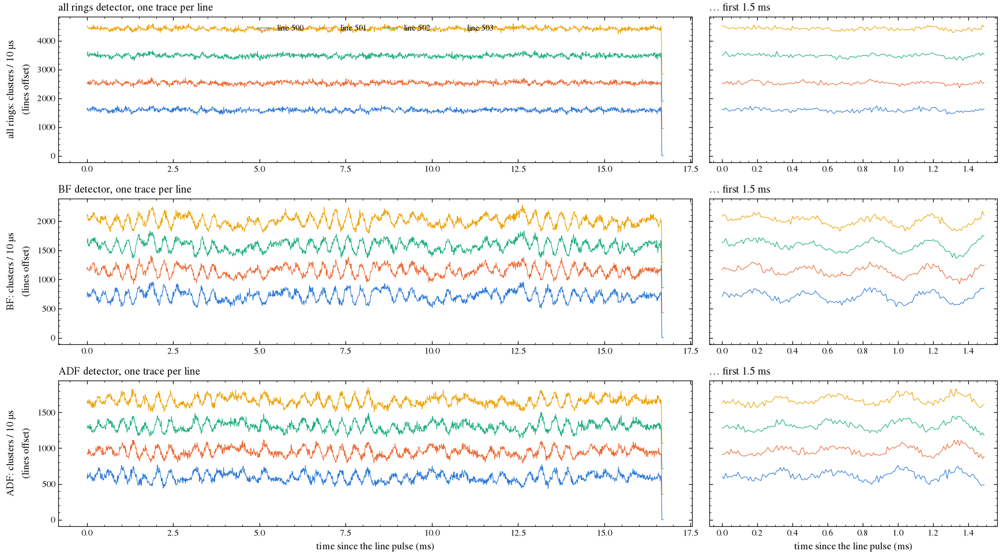

In [12]:
SMOOTH_US = 10  # plot in 10 µs bins
coarse = sample_cube[..., : n_bins // SMOOTH_US * SMOOTH_US].reshape(n_rings, SAMPLE_LINES, -1, SMOOTH_US).sum(-1)
time_ms = np.arange(coarse.shape[-1]) * SMOOTH_US / 1e3
signals = {'all rings': coarse.sum(0), 'BF': coarse[BF_RINGS].sum(0), 'ADF': coarse[ADF_RINGS].sum(0)}

fig, axes = plt.subplots(3, 2, figsize=(16, 9), gridspec_kw={'width_ratios': [2.2, 1]}, sharey='row')
for row, (name, signal) in enumerate(signals.items()):
    step = 0.6 * signal.mean()
    for k in range(SAMPLE_LINES):
        for ax, shown in zip(axes[row], (slice(None), time_ms < 1.5)):
            ax.plot(time_ms[shown], signal[k, shown] + k * step, color=SERIES[k], lw=0.7, label=f'line {SAMPLE_FIRST + k}')
    axes[row, 0].set(ylabel=f'{name}: clusters / 10 µs\n(lines offset)', title=f'{name} detector, one trace per line')
    axes[row, 1].set(title='… first 1.5 ms')
axes[0, 0].legend(loc='upper center', ncols=SAMPLE_LINES)
axes[2, 0].set_xlabel('time since the line pulse (ms)')
axes[2, 1].set_xlabel('time since the line pulse (ms)')
plt.tight_layout()
plt.show()

* **The total count rate is flat**: the beam is never blanked, not even during flyback. The detector
  sees the same current all the time, and only *where* the electrons scatter changes.
* **BF and ADF traces repeat from line to line**: the same bumps at the same time since the pulse.
  Neighboring lines cross nearly the same sample, so the pulse really marks the start of a scan line.
* Where BF has a dip, ADF tends to have a bump. Electrons scattered out of the disk land in the
  darkfield rings, so the two images have opposite contrast.
* Near 15.4 ms the pattern changes character, a first hint of the flyback (section 8).

To put a number on "the lines line up": cross-correlate each ADF line with the next as a function
of a time shift. If the lines were offset from the pulses, the peak would sit away from zero.

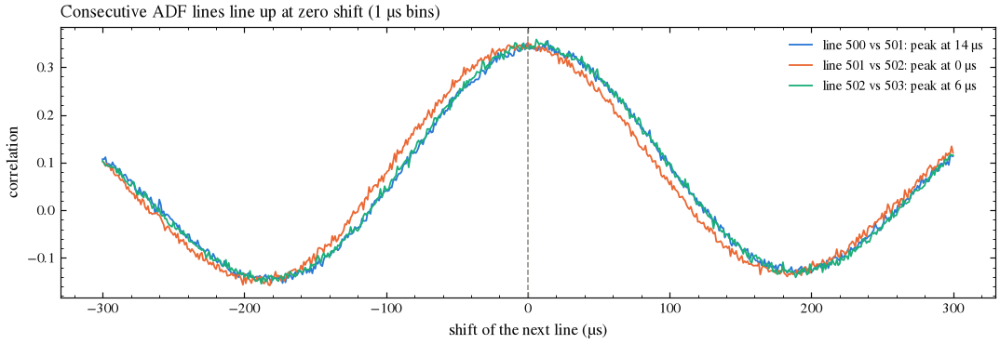

In [13]:
MAX_LAG_US = 300
adf_lines = sample_cube[ADF_RINGS].sum(0).astype(float)[:, :15000]  # the active part of the line, 1 µs bins
lags = np.arange(-MAX_LAG_US, MAX_LAG_US + 1)

fig, ax = plt.subplots(figsize=(10, 3.6))
for k in range(SAMPLE_LINES - 1):
    a = adf_lines[k] - adf_lines[k].mean()
    b = adf_lines[k + 1] - adf_lines[k + 1].mean()
    windows = sliding_window_view(b, len(a) - 2 * MAX_LAG_US)  # b shifted by every lag
    correlation = windows @ a[MAX_LAG_US:-MAX_LAG_US] / (a.std() * b.std() * (len(a) - 2 * MAX_LAG_US))
    ax.plot(
        lags,
        correlation,
        color=SERIES[k],
        lw=1.2,
        label=f'line {SAMPLE_FIRST + k} vs {SAMPLE_FIRST + k + 1}: peak at {lags[correlation.argmax()]} µs',
    )
ax.axvline(0, color=MUTED, lw=1, ls='--')
ax.set(xlabel='shift of the next line (µs)', ylabel='correlation', title='Consecutive ADF lines line up at zero shift (1 µs bins)')
ax.legend()
plt.tight_layout()
plt.show()

All three peaks sit within ~15 µs of zero, about one probe position (section 8). The peaks are broad
because the lattice varies slowly along a line. Section 7 uses longer windows and many lines to do
this more precisely. The peak height is set by shot noise: a 1 µs bin holds ~60 ADF electrons (noise ±8),
while the lattice modulates it by only ±6. The side lobes repeat every ~350 µs, the finest repeat of
the lattice along a line.

## 5. One pass over the whole run

The same `bin_clusters`, applied to every cluster table from `merge_sort` → `cluster_tables`
(notebook 01), streaming: the clusters are counted and dropped, and only the cube is kept:
10 rings × 1024 lines × 16 720 µs of `uint16`, 340 MB. That is the whole scan, kept at full time
resolution and every ring, so all the choices below cost no further passes. The pass reads 230 GB
and clusters 12 G events, ~10 minutes. The cube is cached in `outputs/`.

In [14]:
cube_path = work_directory / 'time_cube.npy'
if cube_path.exists():
    cube = np.load(cube_path)
else:
    cube = np.zeros((n_rings, n_lines, n_bins), np.uint16)
    start = time.perf_counter()
    for table in cluster_tables(merge_sort(files), DT_MAX):
        bin_clusters(
            table.toa.to_numpy(), table.x.to_numpy(), table.y.to_numpy(), pulses, center_x, center_y, RING_EDGES, BIN_TICKS * fine_steps, cube
        )
    seconds = time.perf_counter() - start
    print(f'{seconds / 60:.1f} min, {layout.events.sum() / seconds / 1e6:.0f} M events/s')
    work_directory.mkdir(parents=True, exist_ok=True)
    np.save(cube_path, cube)
print(f'cube {cube.shape}: {cube.sum(dtype=np.int64):,} clusters, largest bin {cube.max()} (uint16 holds 65535)')

cube (10, 1024, 16720): 2,708,509,696 clusters, largest bin 79 (uint16 holds 65535)


## 6. The scan as a function of time

Add up the ADF rings and look at the cube as an image: one row per line, time since the pulse
across, no assumption about the dwell yet. (Displayed in 16 µs bins. The cube itself has 1 µs.)

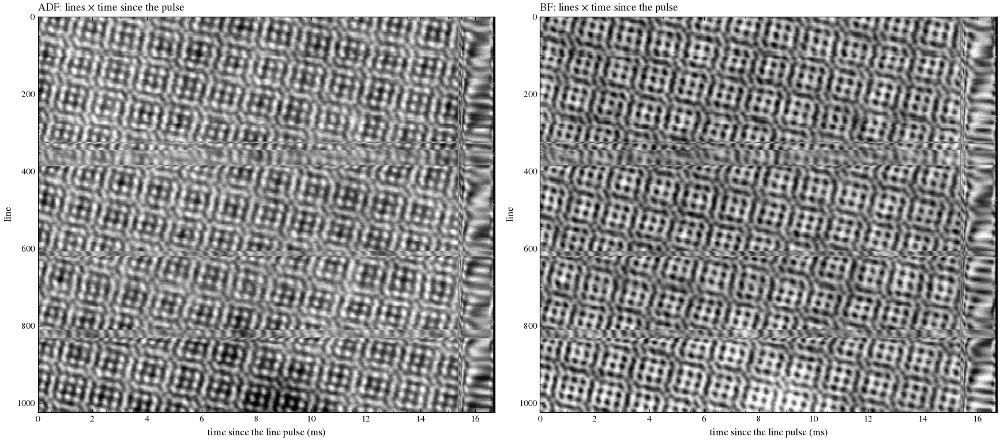

In [15]:
adf_time = cube[ADF_RINGS].sum(0, dtype=np.float32)  # lines x µs since the pulse
bf_time = cube[BF_RINGS].sum(0, dtype=np.float32)
SHOW_US = 16
shown_bins = n_bins // SHOW_US * SHOW_US
extent = (0, shown_bins / 1e3, n_lines, 0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7.2))
for ax, (name, image) in zip(axes, [('ADF', adf_time), ('BF', bf_time)]):
    binned = image[:, :shown_bins].reshape(n_lines, -1, SHOW_US).sum(-1)
    ax.imshow(binned, cmap='gray', aspect='auto', extent=extent, vmin=np.percentile(binned, 0.5), vmax=np.percentile(binned, 99.5))
    ax.set(title=f'{name}: lines × time since the pulse', xlabel='time since the line pulse (ms)', ylabel='line')
    ax.grid(False)
plt.tight_layout()
plt.show()

That is already a darkfield image. The sample is a periodic lattice, and BF and ADF show it with
opposite contrast. Three things to notice:

* At ~15.4 ms the image stops, and a narrow strip begins that looks like the image again,
  **mirrored and squeezed**: the flyback. The beam is not blanked, so it keeps scattering while it
  returns across the sample, and the detector keeps counting.
* A few horizontal bands (around lines 330–380, 610 and 820) where rows are smeared or shifted sideways (section 11).
* The turn-around at ~15.4 ms is a straight vertical line, although line periods differ by up to
  ~50 µs (section 2). That already suggests the scan runs at a **fixed dwell** from each pulse. The next section tests it.

A closer look at the end of the line, at full 1 µs resolution. The black area on the right is past
the line's next pulse, and its ragged edge is the period jitter of section 2.

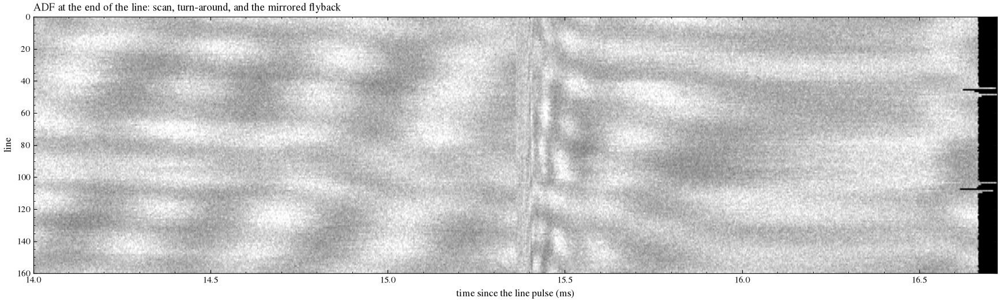

In [16]:
ZOOM_LINES, ZOOM_US = slice(0, 160), slice(14000, n_bins)
kernel = np.ones(4) / 4  # 4 µs running mean against shot noise
zoom = np.apply_along_axis(np.convolve, 1, adf_time[ZOOM_LINES, ZOOM_US], kernel, 'same')

fig, ax = plt.subplots(figsize=(16, 5))
ax.imshow(
    zoom,
    cmap='gray',
    aspect='auto',
    extent=(ZOOM_US.start / 1e3, n_bins / 1e3, ZOOM_LINES.stop, ZOOM_LINES.start),
    vmin=np.percentile(zoom, 1),
    vmax=np.percentile(zoom, 99),
)
ax.set(title='ADF at the end of the line: scan, turn-around, and the mirrored flyback', xlabel='time since the line pulse (ms)', ylabel='line')
ax.grid(False)
plt.tight_layout()
plt.show()

## 7. Fixed dwell, or stretched to each line?

There are two ways to turn "time since the pulse" into a column:

* **fixed dwell**: column = time / dwell. The scan generator steps at its own constant pixel clock
  from each pulse. A long line just ends with extra idle (flyback) time.
* **stretched**: column = time / (this line's period) × columns, as if the scan were stretched to fill
  each line period exactly.

They differ only on lines with an unusual period, and only late in the line: a period 50 µs long
moves the end of a stretched line by ~45 µs, three probe positions. The test: for each line, measure how far its
features are shifted against the **average of the two lines around it** (cross-correlation, as in
section 4). Averaging the line before and the line after cancels the tilt of the lattice, which shifts every line
against the previous one. Do it once in a window at the **start** and once at the **end** of the
scanned part, and plot the shift against the line's own period deviation.

In [17]:
SHIFT_SMOOTH_US = 9
START_WINDOW, END_WINDOW = slice(100, 3100), slice(12300, 15300)  # µs since the pulse, both inside the scanned part


def line_shifts(image, window, max_lag=80):
    """Shift (µs, sub-bin) of each line's features against the mean of the lines before and after it,
    by cross-correlation within window. NaN for the first and last line."""
    smoothed = np.apply_along_axis(np.convolve, 1, image[:, window], np.ones(SHIFT_SMOOTH_US) / SHIFT_SMOOTH_US, 'same')
    smoothed -= smoothed.mean(1, keepdims=True)
    reference = 0.5 * (smoothed[:-2] + smoothed[2:])[:, max_lag:-max_lag]
    correlation = np.einsum('kl,kml->km', reference, sliding_window_view(smoothed[1:-1], reference.shape[1], axis=1))
    best = np.clip(correlation.argmax(1), 1, 2 * max_lag - 1)
    left, middle, right = (correlation[np.arange(len(best)), best + d] for d in (-1, 0, 1))
    shift = best - max_lag + 0.5 * (left - right) / (left - 2 * middle + right)  # parabola through the peak
    return np.concatenate([[np.nan], shift, [np.nan]])


line_period = np.append(period, typical_period)  # ticks; the last line has no closing pulse
stretched_time = np.zeros_like(adf_time)
source_bin = np.arange(n_bins)
for k in range(n_lines):
    target = (source_bin * typical_period / line_period[k]).astype(int)
    np.add.at(stretched_time[k], target[target < n_bins], adf_time[k, target < n_bins])

period_deviation_us = (line_period - typical_period) * TICK_S * 1e6
shifts = {
    (mapping, where): line_shifts(image, window)
    for mapping, image in [('fixed dwell', adf_time), ('stretched', stretched_time)]
    for where, window in [('start', START_WINDOW), ('end', END_WINDOW)]
}
odd = (abs(period_deviation_us) > 20) & np.isfinite(shifts['fixed dwell', 'start'])
for (mapping, where), shift in shifts.items():
    slope = np.polyfit(period_deviation_us[odd], shift[odd], 1)[0]
    print(f'{mapping:>12}, {where:>5} of the line: shift per µs of period deviation {slope:+.2f} (on the {odd.sum()} lines off by > 20 µs)')

 fixed dwell, start of the line: shift per µs of period deviation +0.03 (on the 39 lines off by > 20 µs)
 fixed dwell,   end of the line: shift per µs of period deviation +0.03 (on the 39 lines off by > 20 µs)
   stretched, start of the line: shift per µs of period deviation -0.10 (on the 39 lines off by > 20 µs)
   stretched,   end of the line: shift per µs of period deviation -1.07 (on the 39 lines off by > 20 µs)


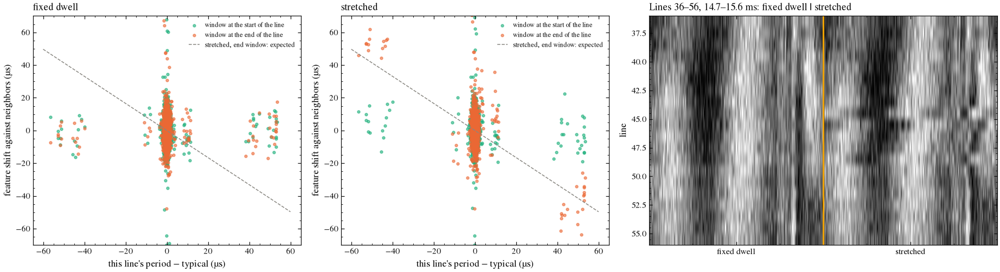

In [18]:
end_center_us = (END_WINDOW.start + END_WINDOW.stop) / 2
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), gridspec_kw={'width_ratios': [1, 1, 1.3]})
for ax, mapping in zip(axes[:2], ['fixed dwell', 'stretched']):
    for where, color in [('start', AQUA), ('end', ORANGE)]:
        ax.scatter(period_deviation_us, shifts[mapping, where], s=10, color=color, alpha=0.6, label=f'window at the {where} of the line')
    x_line = np.array([-60, 60])
    ax.plot(x_line, -x_line * end_center_us / (typical_period * TICK_S * 1e6), color=MUTED, lw=1, ls='--', label='stretched, end window: expected')
    ax.set(xlabel="this line's period − typical (µs)", ylabel='feature shift against neighbors (µs)', title=mapping, ylim=(-70, 70), xlim=(-65, 65))
    ax.legend(loc='upper right', fontsize=8)
zoom_lines = slice(36, 56)  # around the first period jump
compare = np.hstack([image[zoom_lines, 14700:15600] for image in (adf_time, stretched_time)])
compare = np.apply_along_axis(np.convolve, 1, compare, np.ones(4) / 4, 'same')
axes[2].imshow(
    compare,
    cmap='gray',
    aspect='auto',
    extent=(0, 2 * 900, zoom_lines.stop, zoom_lines.start),
    vmin=np.percentile(compare, 1),
    vmax=np.percentile(compare, 99),
)
axes[2].axvline(900, color=YELLOW, lw=2)
axes[2].set(
    title=f'Lines {zoom_lines.start}–{zoom_lines.stop}, 14.7–15.6 ms: fixed dwell | stretched',
    xticks=[450, 1350],
    xticklabels=['fixed dwell', 'stretched'],
    ylabel='line',
)
axes[2].grid(False)
plt.tight_layout()
plt.show()

* **Fixed dwell:** the shift does not depend on the line's period, at the start or at the end of the
  line. A line whose pulse came 50 µs late still has its features exactly where its neighbors have them.
* **Stretched:** at the start of the line the two mappings agree, but at the end the shift follows the
  dashed line. Stretching moves the features of an odd line sideways by almost the whole period difference.
  The right panel shows it directly: the turn-around (the bright vertical line) is straight with fixed
  dwell and jumps sideways on the odd lines when stretched.
* The spread of points around zero (~10 µs) is the precision of the method. The lattice varies slowly along a
  line, which makes a broad correlation peak.

So the scan generator **starts every line at its pulse and then runs on its own fixed pixel clock.**
The pulse irregularities of section 2 change only how long the beam waits at the end of the line.

## 8. Where the scan ends: the dwell time

The step from one probe position to the next leaves no mark in the count rate, but the end of the
line does. When the beam flies back, the diffraction pattern moves slightly on the detector (the
descan does not quite follow a fast deflection), and the total count rate drops. Averaged over all
1024 lines, that step is sharp to a few µs.

the count rate drops by 0.9% at 15363 µs after the pulse
1024 columns in 15363 µs: 15.003 µs per probe position


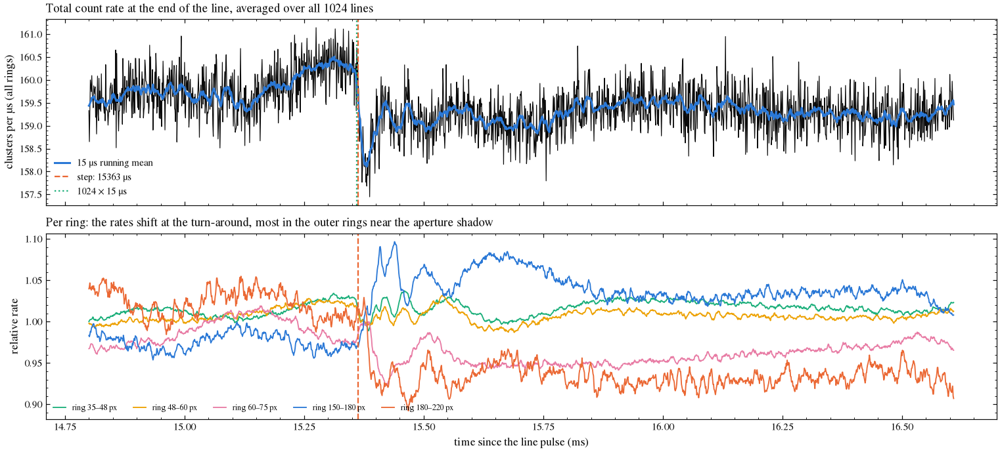

In [19]:
total_profile = cube.sum(0, dtype=np.float64).mean(0)  # clusters per µs, averaged over all lines
STEP_US = 100
candidates = np.arange(14500, 16000)
step = np.array([total_profile[c - STEP_US : c].mean() - total_profile[c : c + STEP_US].mean() for c in candidates])
scan_end_us = int(candidates[step.argmax()])  # first µs after the drop
N_COLUMNS = n_lines  # assume a square scan: as many probe positions per line as lines
print(f'the count rate drops by {step.max() / total_profile[:scan_end_us].mean():.1%} at {scan_end_us} µs after the pulse')
print(f'{N_COLUMNS} columns in {scan_end_us} µs: {scan_end_us / N_COLUMNS:.3f} µs per probe position')
DWELL_US = round(scan_end_us / N_COLUMNS)

shown = slice(14800, int(period.min()) // BIN_TICKS)  # up to the end of the shortest line, so every line contributes
t_ms = np.arange(shown.start, shown.stop) / 1e3
fig, (ax_total, ax_rings) = plt.subplots(2, 1, figsize=(14, 6.5), sharex=True)
ax_total.plot(t_ms, total_profile[shown], color=INK, lw=0.8)
ax_total.plot(t_ms, np.convolve(total_profile, np.ones(15) / 15, 'same')[shown], color=BLUE, lw=2, label='15 µs running mean')
ax_total.axvline(scan_end_us / 1e3, color=ORANGE, lw=1.5, ls='--', label=f'step: {scan_end_us} µs')
ax_total.axvline(N_COLUMNS * DWELL_US / 1e3, color=AQUA, lw=1.5, ls=':', label=f'{N_COLUMNS} × {DWELL_US} µs')
ax_total.set(ylabel='clusters per µs (all rings)', title='Total count rate at the end of the line, averaged over all 1024 lines')
ax_total.legend(loc='lower left')
for k in [2, 3, 4, 8, 9]:
    ring_profile = np.convolve(cube[k].mean(0, dtype=np.float64), np.ones(9) / 9, 'same')
    ax_rings.plot(
        t_ms, ring_profile[shown] / ring_profile[2000:14000].mean(), lw=1.2, color=SERIES[k % len(SERIES)], label=f'ring {ring_names[k]} px'
    )
ax_rings.axvline(scan_end_us / 1e3, color=ORANGE, lw=1.5, ls='--')
ax_rings.set(
    xlabel='time since the line pulse (ms)',
    ylabel='relative rate',
    title='Per ring: the rates shift at the turn-around, most in the outer rings near the aperture shadow',
)
ax_rings.legend(loc='lower left', ncols=5, fontsize=8)
plt.tight_layout()
plt.show()

The step lands **within a few µs of 1024 × 15 µs = 15.36 ms**. The scan is 1024 × 1024 probe
positions at a **15 µs dwell**, a round number of the kind one would set on a scan generator. The line takes
15.36 ms, and the remaining ~1.3 ms of each 16.67 ms line period is flyback plus the wait for the next
mains-locked pulse. So 92 % of the beam time goes into the image, and the electrons of the other 8 % are dropped.

The ring traces explain the step. At the turn-around the rates change most in the outer rings, next to
the sharp shadow of the aperture: the pattern moves a little on the detector while the beam is swung back,
and electrons near the shadow edge cross it. The rings with smooth intensity hardly notice.

## 9. The darkfield image

Column = µs since the pulse ÷ 15, for the first 1024 × 15 µs of every line: group the cube's 1 µs bins in
fifteens. One count is one electron.

electrons per probe position: ADF 888, BF 1084, all rings 2380
92.1% of the binned clusters fall inside the 1024 x 1024 scan, the rest in the flyback


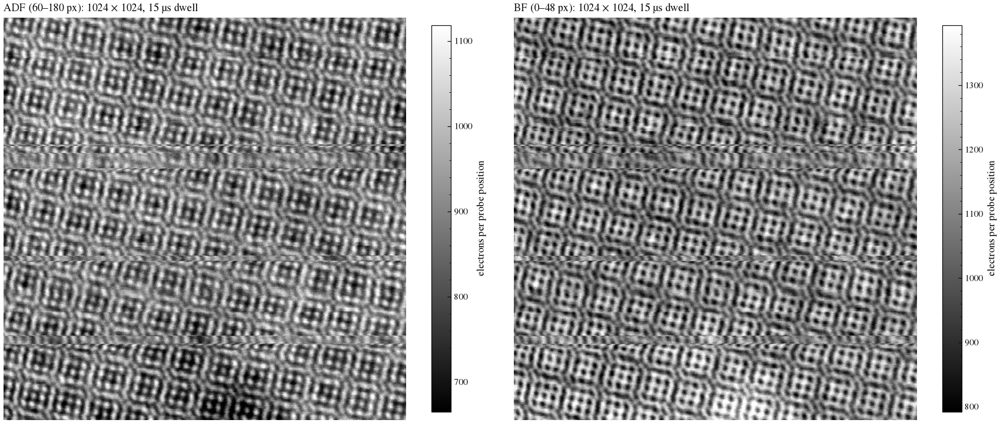

In [20]:
scan = cube[..., : N_COLUMNS * DWELL_US].reshape(n_rings, n_lines, N_COLUMNS, DWELL_US).sum(-1, dtype=np.float32)  # ring x line x column
adf_image = scan[ADF_RINGS].sum(0)
bf_image = scan[BF_RINGS].sum(0)
print(f'electrons per probe position: ADF {adf_image.mean():.0f}, BF {bf_image.mean():.0f}, all rings {scan.sum(0).mean():.0f}')
print(f'{scan.sum() / cube.sum(dtype=np.int64):.1%} of the binned clusters fall inside the 1024 x 1024 scan, the rest in the flyback')

fig, axes = plt.subplots(1, 2, figsize=(16, 7.8))
for ax, (name, image) in zip(axes, [('ADF (60–180 px)', adf_image), ('BF (0–48 px)', bf_image)]):
    shown = ax.imshow(image, cmap='gray', vmin=np.percentile(image, 0.5), vmax=np.percentile(image, 99.5))
    fig.colorbar(shown, ax=ax, shrink=0.8, label='electrons per probe position')
    ax.set(title=f'{name}: 1024 × 1024, {DWELL_US} µs dwell')
    no_grid(ax)
plt.tight_layout()
plt.show()

**Up close, and the noise.** Each probe position collects ~900 ADF electrons. Shot noise (√N) is
3.4 % of that, and the lattice modulates it by 10 % rms. The histogram compares the spread of the
counts with the spread Poisson statistics alone would give: the excess is the image.

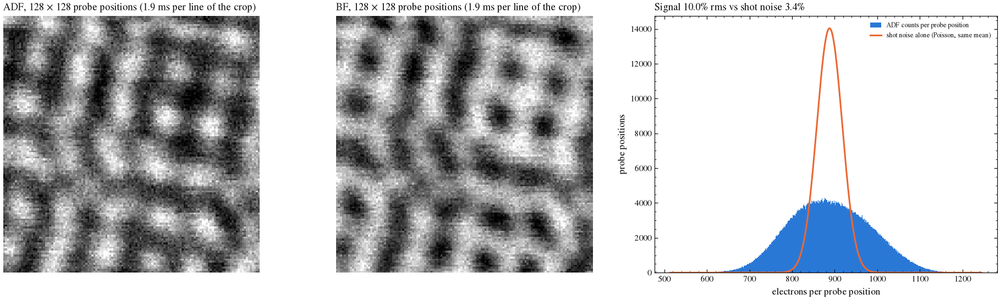

In [21]:
ZOOM = (slice(100, 228), slice(100, 228))
signal_std = np.sqrt(adf_image.var() - adf_image.mean())  # remove Poisson variance (= mean)
fig, (ax_adf, ax_bf, ax_hist) = plt.subplots(1, 3, figsize=(17, 5.2), gridspec_kw={'width_ratios': [1, 1, 1.2]})
for ax, (name, image) in zip((ax_adf, ax_bf), [('ADF', adf_image), ('BF', bf_image)]):
    crop = image[ZOOM]
    ax.imshow(crop, cmap='gray', vmin=np.percentile(crop, 0.5), vmax=np.percentile(crop, 99.5))
    ax.set(title=f'{name}, 128 × 128 probe positions (1.9 ms per line of the crop)')
    no_grid(ax)
counts = np.arange(adf_image.min(), adf_image.max() + 1)
ax_hist.hist(adf_image.ravel(), bins=counts, color=BLUE, label='ADF counts per probe position')
poisson = len(adf_image.ravel()) * np.exp(-0.5 * (counts - adf_image.mean()) ** 2 / adf_image.mean()) / np.sqrt(2 * np.pi * adf_image.mean())
ax_hist.plot(counts, poisson, color=ORANGE, lw=2, label='shot noise alone (Poisson, same mean)')
ax_hist.set(
    xlabel='electrons per probe position',
    ylabel='probe positions',
    title=f'Signal {signal_std / adf_image.mean():.1%} rms vs shot noise {1 / np.sqrt(adf_image.mean()):.1%}',
)
ax_hist.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

## 10. Choosing the collection angle

The cube kept every ring separately, so each ring is its own virtual detector. With a convergence
semi-angle of 15 mrad (folder name) and the disk edge at 55 px, one detector pixel is about
15/55 ≈ 0.27 mrad, and the rings span 0–60 mrad. Each ring image below is divided by its own mean, and all share one
gray scale (±25 %).

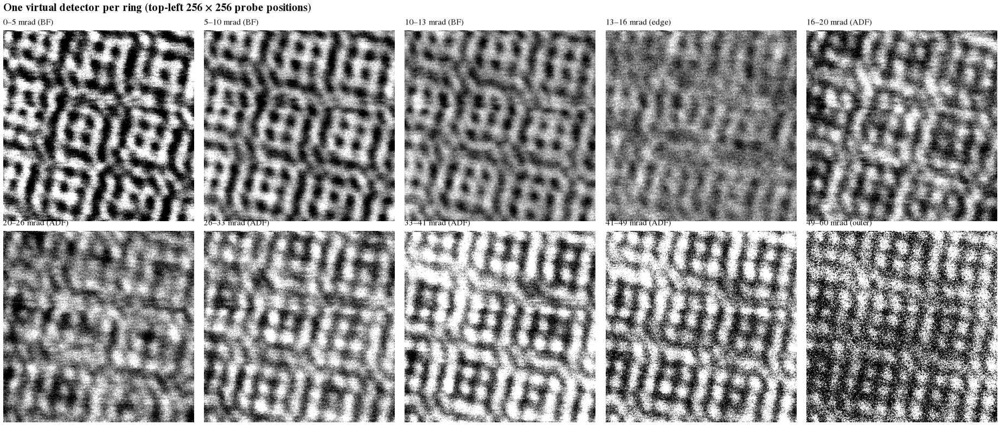

In [22]:
MRAD_PER_PX = 15 / bf_radius  # 15 mrad convergence semi-angle (run folder name) at the disk edge
ring_images = scan / scan.mean(axis=(1, 2), keepdims=True)

fig, axes = plt.subplots(2, 5, figsize=(17, 7.4))
for k, ax in enumerate(axes.flat):
    ax.imshow(ring_images[k, :256, :256], cmap='gray', vmin=0.75, vmax=1.25)
    group = 'BF' if k < BF_RINGS.stop else ('ADF' if ADF_RINGS.start <= k < ADF_RINGS.stop else 'edge' if k == BF_RINGS.stop else 'outer')
    ax.set_title(f'{RING_EDGES[k] * MRAD_PER_PX:.0f}–{RING_EDGES[k + 1] * MRAD_PER_PX:.0f} mrad ({group})', fontsize=10)
    no_grid(ax)
fig.suptitle('One virtual detector per ring (top-left 256 × 256 probe positions)', x=0.01, ha='left', fontweight='bold')
plt.tight_layout()
plt.show()

* **0–13 mrad (inside the disk):** BF contrast, strongest in the middle of the disk.
* **13–16 mrad (the disk edge):** almost no contrast. BF and DF contributions cancel at the edge.
* **16–49 mrad (ADF):** reversed contrast. The finer details (the 2 × 2 dots inside each cell)
  sharpen as the angle grows, as expected when moving from diffraction contrast toward incoherent,
  high-angle (Z-contrast-like) scattering.
* **49–60 mrad:** the same contrast, but noisy: few electrons get past the aperture.

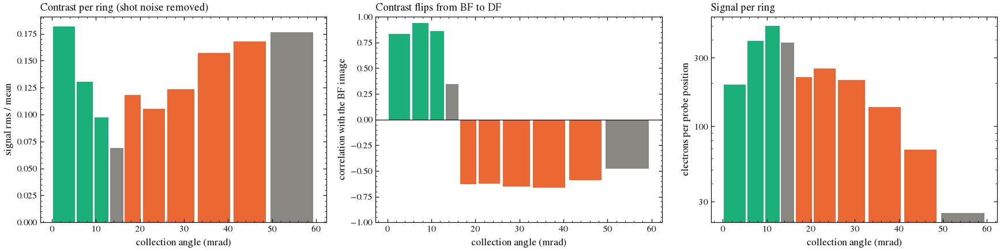

,mrad,electrons / position,contrast,corr. with BF,signal / shot noise
ring (px),,,,,
0–20,0–5,194.0,0.182,0.83,2.5
20–35,5–10,393.0,0.131,0.94,2.6
35–48,10–13,497.0,0.097,0.86,2.2
48–60,13–16,383.0,0.069,0.35,1.3
60–75,16–20,220.0,0.118,-0.63,1.7
75–95,20–26,253.0,0.105,-0.62,1.7
95–120,26–33,210.0,0.124,-0.65,1.8
120–150,33–41,136.0,0.157,-0.66,1.8
150–180,41–49,69.0,0.168,-0.59,1.4


In [23]:
reference = (bf_image - bf_image.mean()).ravel()
ring_center_mrad = (RING_EDGES[:-1] + RING_EDGES[1:]) / 2 * MRAD_PER_PX
contrast, against_bf, electrons = [], [], []
for k in range(n_rings):
    image = scan[k]
    contrast.append(np.sqrt(max(image.var() - image.mean(), 0)) / image.mean())  # signal rms / mean, shot noise removed
    against_bf.append(np.corrcoef(image.ravel(), reference)[0, 1])
    electrons.append(image.mean())

fig, (ax_contrast, ax_sign, ax_count) = plt.subplots(1, 3, figsize=(16, 4.2))
colors = [AQUA if k < BF_RINGS.stop else (ORANGE if ADF_RINGS.start <= k < ADF_RINGS.stop else MUTED) for k in range(n_rings)]
ax_contrast.bar(ring_center_mrad, contrast, width=np.diff(RING_EDGES) * MRAD_PER_PX * 0.9, color=colors)
ax_contrast.set(xlabel='collection angle (mrad)', ylabel='signal rms / mean', title='Contrast per ring (shot noise removed)')
ax_sign.bar(ring_center_mrad, against_bf, width=np.diff(RING_EDGES) * MRAD_PER_PX * 0.9, color=colors)
ax_sign.axhline(0, color=INK, lw=0.8)
ax_sign.set(xlabel='collection angle (mrad)', ylabel='correlation with the BF image', title='Contrast flips from BF to DF', ylim=(-1, 1))
ax_count.bar(ring_center_mrad, electrons, width=np.diff(RING_EDGES) * MRAD_PER_PX * 0.9, color=colors)
ax_count.set(xlabel='collection angle (mrad)', ylabel='electrons per probe position', title='Signal per ring', yscale='log')
ax_count.set_yticks([30, 100, 300], ['30', '100', '300'])  # about a decade: plain labels
ax_count.tick_params(axis='y', which='minor', labelleft=False)
plt.tight_layout()
plt.show()
pd.DataFrame(
    {
        'ring (px)': ring_names,
        'mrad': [f'{a * MRAD_PER_PX:.0f}–{b * MRAD_PER_PX:.0f}' for a, b in pairwise(RING_EDGES)],
        'electrons / position': np.round(electrons),
        'contrast': np.round(contrast, 3),
        'corr. with BF': np.round(against_bf, 2),
        'signal / shot noise': np.round(np.array(contrast) * np.sqrt(electrons), 1),
    }
).set_index('ring (px)')

Contrast (signal rms ÷ mean) is lowest at the disk edge and rises toward high angles. But the
electrons per probe position fall by ~4× from 20 to 45 mrad, and what matters for seeing the
lattice is contrast × √N (last column). By that measure the 16–41 mrad rings are all about equally useful, so the
default ADF detector (rings 16–49 mrad) adds them together. The outermost ring alone has the
highest contrast but too few electrons. To favor the high-angle contrast, drop the inner ADF rings:
`scan[6:9].sum(0)`.

## 11. Disturbances: line-sync jumps and the horizontal bands

Two kinds of irregularity are left. **The pulse jumps** of section 2 are handled: every line starts at its own
pulse (section 7). **The bands** at lines ~330–380, ~610 and ~820 look different. Compare the electrons per line, the pulse timing, and the
image there:

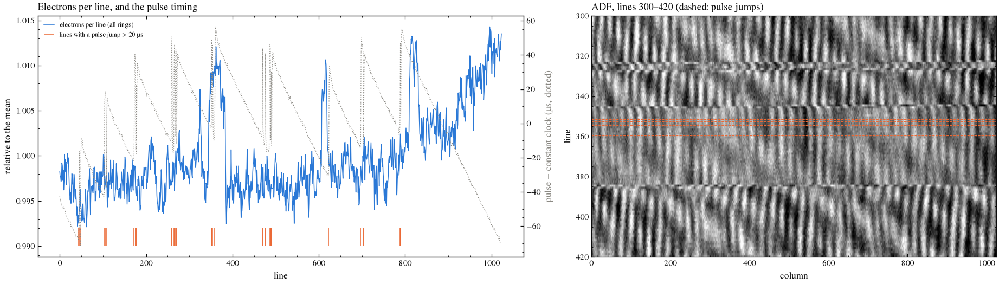

In [24]:
per_line = scan.sum(axis=(0, 2))
jumps = np.flatnonzero(abs(period_deviation_us) > 20)
BAND = slice(300, 420)

fig, (ax_line, ax_band) = plt.subplots(1, 2, figsize=(17, 5), gridspec_kw={'width_ratios': [1.2, 1]})
ax_line.plot(line, per_line / per_line.mean(), color=BLUE, lw=1, label='electrons per line (all rings)')
ax_line.vlines(jumps, 0.99, 0.992, color=ORANGE, lw=1, label='lines with a pulse jump > 20 µs')
ax_line.tick_params(which='both', right=False)  # the right axis belongs to the twin
ax_drift_twin = ax_line.twinx()
ax_drift_twin.plot(line, drift_us, color=MUTED, lw=0.8, ls=':')
ax_drift_twin.set_ylabel('pulse − constant clock (µs, dotted)', color=MUTED)
ax_drift_twin.grid(False)
ax_line.set(xlabel='line', ylabel='relative to the mean', title='Electrons per line, and the pulse timing')
ax_line.legend(loc='upper left', fontsize=8)
crop = adf_image[BAND]
ax_band.imshow(
    crop, cmap='gray', aspect='auto', extent=(0, N_COLUMNS, BAND.stop, BAND.start), vmin=np.percentile(crop, 0.5), vmax=np.percentile(crop, 99.5)
)
for k in jumps[(jumps >= BAND.start) & (jumps < BAND.stop)]:
    ax_band.axhline(k + 0.5, color=ORANGE, lw=0.8, ls='--')
ax_band.set(title=f'ADF, lines {BAND.start}–{BAND.stop} (dashed: pulse jumps)', xlabel='column', ylabel='line')
ax_band.grid(False)
plt.tight_layout()
plt.show()

* The electrons per line drift by ~1 % over the frame, and step up at the bands at ~350–380 and ~610.
* The bands sit **near** pulse jumps (around lines 355, 623, 790). But most jumps (lines 45, 105, 175,
  260, 470–490, 700) leave the image untouched, and the 330–380 band lasts tens of lines. Section 7 already showed
  that a jump by itself moves nothing. A common outside cause is plausible (a disturbance on the mains that
  shifts the line sync *and* upsets the beam or the scan), but this data can't tell.
* Inside the bands the image is smeared or shifted sideways by several probe positions. That is a
  change in where the beam actually was. No choice of timing can undo it.

**Is the pixel grid square?** The Fourier transform of the ADF image shows the lattice as sharp
spots. If the dwell were wrong (or the field of view not square), the image would be stretched
along one axis, and the two lattice spots would differ in length or not be perpendicular.

spot at (fx, fy) = (+0.01074, +0.00278): lattice period 90.2 probe positions, direction 14.5°
spot at (fx, fy) = (-0.00267, +0.01059): lattice period 91.6 probe positions, direction 104.1°
ratio of the two periods 0.985, angle between them 89.6°


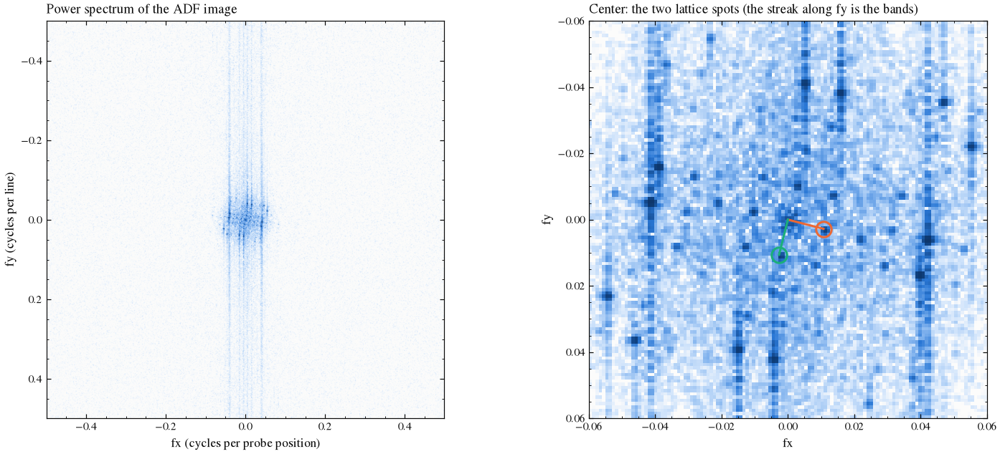

In [25]:
window_2d = np.outer(np.hanning(n_lines), np.hanning(N_COLUMNS))
power = np.abs(np.fft.fftshift(np.fft.fft2((adf_image - adf_image.mean()) * window_2d))) ** 2
frequency = np.fft.fftshift(np.fft.fftfreq(N_COLUMNS))  # cycles per probe position (= per line along y)
fy, fx = np.meshgrid(frequency, frequency, indexing='ij')
angle = np.arctan2(fy, fx)
lattice_band = (np.hypot(fx, fy) > 1 / 150) & (np.hypot(fx, fy) < 1 / 30) & (fy >= 0)  # periods of 30-150 positions, one half-plane
first = np.unravel_index(np.where(lattice_band, power, 0).argmax(), power.shape)
perpendicular = abs(np.sin(angle - angle[first])) > 0.95
second = np.unravel_index(np.where(lattice_band & perpendicular, power, 0).argmax(), power.shape)
spots = []
for row, col in (first, second):
    near = (slice(row - 2, row + 3), slice(col - 2, col + 3))  # power-weighted centroid: sub-bin spot position
    spot_fx, spot_fy = (np.sum(f[near] * power[near]) / power[near].sum() for f in (fx, fy))
    spots.append((spot_fx, spot_fy))
    print(
        f'spot at (fx, fy) = ({spot_fx:+.5f}, {spot_fy:+.5f}): lattice period {1 / np.hypot(spot_fx, spot_fy):.1f} probe positions, direction {np.degrees(np.arctan2(spot_fy, spot_fx)):.1f}°'
    )
(ax_, ay_), (bx_, by_) = spots
print(
    f'ratio of the two periods {np.hypot(bx_, by_) / np.hypot(ax_, ay_):.3f}, angle between them {np.degrees(abs(np.arctan2(ay_, ax_) - np.arctan2(by_, bx_))):.1f}°'
)

fig, (ax_fft, ax_zoom) = plt.subplots(1, 2, figsize=(14, 6))
norm = LogNorm(vmin=np.percentile(power, 60), vmax=power.max())
ax_fft.imshow(power, cmap=SEQUENTIAL, norm=norm, extent=(frequency[0], frequency[-1], frequency[-1], frequency[0]))
ax_fft.set(title='Power spectrum of the ADF image', xlabel='fx (cycles per probe position)', ylabel='fy (cycles per line)')
ax_fft.grid(False)
reach = 0.06
middle, pixels = N_COLUMNS // 2, int(0.06 * N_COLUMNS)
ax_zoom.imshow(
    power[middle - pixels : middle + pixels, middle - pixels : middle + pixels], cmap=SEQUENTIAL, norm=norm, extent=(-reach, reach, reach, -reach)
)
for (spot_fx, spot_fy), color in zip(spots, (ORANGE, AQUA)):
    ax_zoom.plot([0, spot_fx], [0, spot_fy], color=color, lw=2)
    ax_zoom.plot(spot_fx, spot_fy, 'o', mfc='none', mec=color, ms=14, mew=2)
ax_zoom.set(title='Center: the two lattice spots (the streak along fy is the bands)', xlabel='fx', ylabel='fy')
ax_zoom.grid(False)
plt.tight_layout()
plt.show()

The two strongest lattice spots have periods of 90.2 and 91.6 probe positions, 89.6° apart, and the
lattice is tilted by 14.5° against the scan. If the lattice is square on the sample, it comes out square
in the image to within ~2 %, which is about the precision of locating a spot on a 1024-point transform.
So 1024 columns of 15 µs give square probe positions. The vertical streaks are the horizontal bands of
the last figure.

## 12. Summary, and saving the images

In [26]:
np.savez_compressed(
    work_directory / 'scan_images.npz',
    ring_images=scan.astype(np.uint32),
    ring_edges_px=RING_EDGES,
    adf=adf_image.astype(np.uint32),
    bf=bf_image.astype(np.uint32),
    dwell_us=DWELL_US,
    center=(center_x, center_y),
)
print('saved', work_directory / 'scan_images.npz')

saved /Users/7c2/Documents/GitHub/Kronos/outputs/2026_10_08_NNO_200kV_15mrad/scan_images.npz


**What the timing says about this scan**

| quantity | value | from |
|---|---|---|
| pulses | 1024 LVDS rising edges, one per line, in fine units (1/128 tick) | section 2 |
| line period | 16.666 ms, mains-locked (60.00 Hz); ±1 µs jitter, occasional jumps of up to ~60 µs | section 2 |
| line start | at each line's own pulse; the scan does not stretch with the period | sections 4, 7 |
| dwell | 15 µs, fixed (the flyback step is at 15 363 µs ≈ 1024 × 15 µs) | section 8 |
| scan | 1024 × 1024 square probe positions; 15.36 ms per line, then ~1.3 ms of flyback and wait | sections 8, 11 |
| signal | ~2400 electrons per probe position, ~900 of them in the ADF rings (16–49 mrad) | sections 9, 10 |

**The recipe** (`bin_clusters`): line = last pulse before the cluster; column = (time since that
pulse) // dwell; detector = the ring the cluster lands in. One streaming pass (~10 min for 12 G events)
fills a cube of rings × lines × 1 µs time bins. The dwell, the columns and the virtual detector are then
all chosen afterwards without touching the raw data again. `outputs/<run>/scan_images.npz` holds the per-ring
images, the ADF and BF images, and the geometry.

**Things to keep in mind**

* The metadata (`scan_*` = −1, `ttl_timestamp` as the trigger) did not describe this run. The pulses came
  on LVDS, one per line, and the geometry had to be measured. The checks here (the flyback step in the total
  rate, the fixed-dwell test, square lattice spots) are cheap to repeat on every new run.
* The beam is not blanked during flyback, so 8 % of the electrons belong to no probe position. The cube keeps them,
  the image drops them.
* Count clusters, not events: at 200 kV an electron fires ~4 pixels, and fewer in the bright disk (dead
  time), so an event-count image would be biased between BF and DF.
* The bands at lines ~330–380, ~610 and ~820 are real beam or scan disturbances, not timing errors.